# Match me up

In [85]:
# imports
import earthaccess

import os
import numpy as np

import pandas
from matplotlib import pyplot as plt
from shapely.geometry import Polygon, Point

from ocpy.utils import io as ocpy_io
from remote_sensing.plotting import globe

import gpolygons

# Authenticate

In [2]:
auth = earthaccess.login(persist=True)

# defs

In [24]:
def datetime_date(dtime):
    return str(dtime.date())

In [32]:
def neg_lon(lon):
    if lon > 180.:
        lon = lon-360
    return lon

# Load up BGC

In [4]:
df = pandas.read_csv('argo_bgc_profiles_bbp.csv')

## Cut on date

In [16]:
time = pandas.to_datetime(df.time.values)
old_enough = time > pandas.Timestamp('2024-04-01')

In [19]:
argo_pace = df[old_enough]
pace_times = pandas.to_datetime(time[old_enough])

# Loop and see if we can match-up

In [ ]:
for ss in range(len(argo_pace)):
    

In [7]:
irow = argo_pace.iloc[0]
irow

cruise                               1902304
filename                        1902304QC.nc
profile                                  158
lat                                   56.325
lon                                  341.013
time           2024-04-10 21:11:00.000001024
solar_angle                        -8.083862
Name: 261, dtype: object

In [37]:
next_day = pace_times[0] + pandas.Timedelta('200 day')
tspan = (datetime_date(pace_times[0]), datetime_date(next_day))
tspan

('2024-04-10', '2024-10-27')

In [33]:
bbox = (neg_lon(irow.lon - 0.1), irow.lat-0.1, neg_lon(irow.lon + 0.1), irow.lat + 0.1)
bbox

(np.float64(-19.087000000000046),
 np.float64(56.225),
 np.float64(-18.887),
 np.float64(56.425000000000004))

In [43]:
results = earthaccess.search_data(
     short_name="PACE_OCI_L2_AOP",
     temporal=tspan,
     bounding_box=bbox,
     cloud_cover=(0,50),
 )
results

[Collection: {'ShortName': 'PACE_OCI_L2_AOP', 'Version': '3.0'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 66.64554, 'Longitude': 28.98771}, {'Latitude': 58.53783, 'Longitude': -22.87468}, {'Latitude': 42.96193, 'Longitude': -6.73448}, {'Latitude': 49.01011, 'Longitude': 27.32508}, {'Latitude': 66.64554, 'Longitude': 28.98771}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-26T11:46:08Z', 'EndingDateTime': '2024-06-26T11:51:08Z'}}
 Size(MB): 206.3852243423462
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240626T114608.L2.OC_AOP.V3_0.nc'],
 Collection: {'ShortName': 'PACE_OCI_L2_AOP', 'Version': '3.0'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 62.38693, 'Longitude': 21.0178}, {'Latitude': 55.00705, 'Longitude': -24.79457}, {'Latitude': 38.88563, 'Longitude': -11.26573}, {'Latitude'

In [44]:
type(results[0])

earthaccess.results.DataGranule

In [46]:
granule = results[0]

In [47]:
granule['meta']

{'concept-type': 'granule',
 'concept-id': 'G3404371323-OB_CLOUD',
 'revision-id': 1,
 'native-id': 'PACE_OCI_L2_AOP_PACE_OCI.20240626T114608.L2.OC_AOP.V3_0.nc_3.0',
 'collection-concept-id': 'C3385049983-OB_CLOUD',
 'provider-id': 'OB_CLOUD',
 'format': 'application/vnd.nasa.cmr.umm+json',
 'revision-date': '2025-02-12T11:49:15.279Z'}

In [49]:
granule['umm']

{'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2024-06-26T11:46:08Z',
   'EndingDateTime': '2024-06-26T11:51:08Z'}},
 'GranuleUR': 'PACE_OCI_L2_AOP_PACE_OCI.20240626T114608.L2.OC_AOP.V3_0.nc_3.0',
 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 66.64554,
         'Longitude': 28.98771},
        {'Latitude': 58.53783, 'Longitude': -22.87468},
        {'Latitude': 42.96193, 'Longitude': -6.73448},
        {'Latitude': 49.01011, 'Longitude': 27.32508},
        {'Latitude': 66.64554, 'Longitude': 28.98771}]}}]}}},
 'ProviderDates': [{'Date': '2025-02-10T20:50:21Z', 'Type': 'Insert'},
  {'Date': '2025-02-10T20:22:45.246Z', 'Type': 'Update'}],
 'CollectionReference': {'ShortName': 'PACE_OCI_L2_AOP', 'Version': '3.0'},
 'RelatedUrls': [{'Type': 'GET RELATED VISUALIZATION',
   'MimeType': 'image/png',
   'URL': 'https://oceandata.sci.gsfc.nasa.gov/browse_images/PACE_OCI.20240626T114608.L2.OC_AOP.V3_0.nc.png',
   'Form

# Grab all with cloud cover < 50%

In [51]:
all_results = earthaccess.search_data(
     short_name="PACE_OCI_L2_AOP",
     cloud_cover=(0,50),
)

In [52]:
len(all_results)

4654

In [55]:
ex_sp = gpolygons.extract_spatial_extent(all_results[0])
ex_sp

{'bounding_rectangles': [],
 'gpolygons': [{'boundary_points': [(129.99634, 19.95012),
    (105.26324, 14.80566),
    (109.51402, -2.95512),
    (133.20255, 2.08065),
    (129.99634, 19.95012)],
   'exclusive_zones': []}],
 'points': [],
 'lines': []}

In [57]:
geometries = gpolygons.create_shapely_geometries(ex_sp)
geometries

{'polygons': [<POLYGON ((129.996 19.95, 105.263 14.806, 109.514 -2.955, 133.203 2.081, 129...>],
 'rectangles': [],
 'points': [],
 'lines': []}

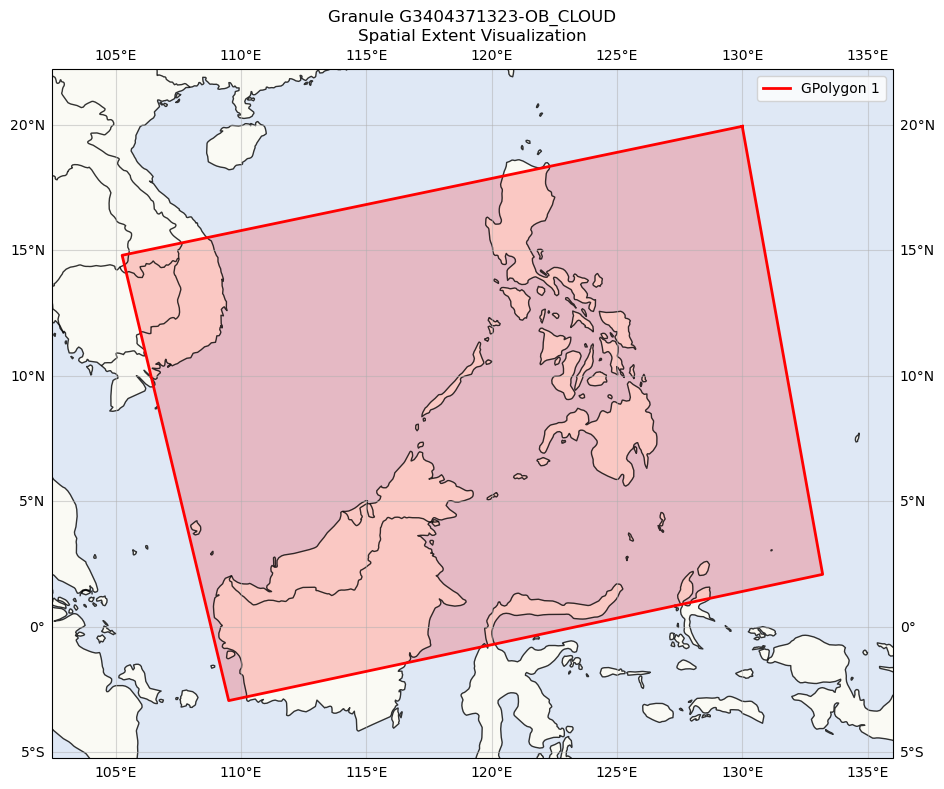

In [63]:
fig = gpolygons.plot_spatial_extent(ex_sp, geometries, 
                         f"Granule {granule.get('meta', {}).get('concept-id', 'Unknown')}")

plt.tight_layout()
plt.show()

In [74]:
point = Point(120., 5.)  # lon, lat

In [73]:
geometries['polygons'][0].contains(point)

True

In [78]:
type(all_results[0]['meta'])

dict

In [75]:
type(all_results[0]['umm'])

dict

In [79]:
all_results[0]['meta']

{'concept-type': 'granule',
 'concept-id': 'G3401489227-OB_CLOUD',
 'revision-id': 1,
 'native-id': 'PACE_OCI_L2_AOP_PACE_OCI.20240305T045359.L2.OC_AOP.V3_0.nc_3.0',
 'collection-concept-id': 'C3385049983-OB_CLOUD',
 'provider-id': 'OB_CLOUD',
 'format': 'application/vnd.nasa.cmr.umm+json',
 'revision-date': '2025-02-10T18:14:16.685Z'}

# Save a JSON file 

In [80]:
full_dict = {}
for iresult in all_results:
    key = iresult['meta']['native-id']
    #
    full_dict[key] = {}
    for ikey in ['meta', 'umm']:
        full_dict[key][ikey] = iresult[ikey]

In [84]:
list(full_dict.keys())[0:2]

['PACE_OCI_L2_AOP_PACE_OCI.20240305T045359.L2.OC_AOP.V3_0.nc_3.0',
 'PACE_OCI_L2_AOP_PACE_OCI.20240305T081040.L2.OC_AOP.V3_0.nc_3.0']

## Save

In [86]:
jdict = ocpy_io.jsonify(full_dict)

In [88]:
ocpy_io.savejson('PACE_50clouds.json', jdict)